# Sparse Norm-Control Tuning (Colab Ready)

This notebook tunes **norm-control choices only** for ORION sparse attention.

Tuned axis (8 combinations):
- `qk_norm` in `{False, True}`
- `ortho_init` in `{False, True}`
- `spectral_norm` in `{False, True}`

Everything else is fixed (`window`, `degree`, model size, seq_len, lr) so the comparison is clean.

Pipeline:
1. Stage 1: short runs for all 8 norm combinations
2. Stage 2: confirm top-k with larger budget and more seeds
3. Select best combination by quality-first score and export final config


In [1]:
import os
import shutil
import subprocess
import sys
import time
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
USE_GOOGLE_DRIVE = True
REPO_URL = "https://github.com/akashkguw/orion.git"
REPO_REF = os.environ.get("ORION_GIT_REF", "main")  # set to branch/tag/sha if needed

if IN_COLAB and USE_GOOGLE_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)
    DRIVE_ROOT = Path("/content/drive/MyDrive/orion")
    REPO_ROOT = DRIVE_ROOT / "repo"
    DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
else:
    REPO_ROOT = Path("/content/orion") if IN_COLAB else Path.cwd()


def _run(
    cmd: list[str], *, cwd: Path | None = None, check: bool = True
) -> subprocess.CompletedProcess:
    proc = subprocess.run(cmd, cwd=str(cwd) if cwd else None, text=True, capture_output=True)
    if check and proc.returncode != 0:
        raise RuntimeError(
            f"Command failed ({' '.join(cmd)}):\nSTDOUT:\n{proc.stdout}\nSTDERR:\n{proc.stderr}"
        )
    return proc


def _is_git_repo(path: Path) -> bool:
    return (path / ".git").exists()


def _clone_repo(repo_url: str, repo_root: Path, retries: int = 3) -> None:
    last_error = "unknown"
    for attempt in range(1, retries + 1):
        proc = subprocess.run(
            ["git", "clone", repo_url, str(repo_root)],
            text=True,
            capture_output=True,
        )
        if proc.returncode == 0:
            return

        last_error = (proc.stderr or proc.stdout or "clone failed").strip()
        tail = last_error.splitlines()[-1] if last_error else "clone failed"
        print(f"Clone attempt {attempt}/{retries} failed: {tail}")

        if repo_root.exists() and not _is_git_repo(repo_root):
            shutil.rmtree(repo_root, ignore_errors=True)

        if attempt < retries:
            time.sleep(attempt)

    raise RuntimeError(f"Failed to clone repository after {retries} attempts: {last_error}")


def _sync_repo(repo_root: Path, ref: str) -> None:
    # Fail fast on dirty trees so runs stay reproducible.
    status = _run(["git", "status", "--porcelain"], cwd=repo_root)
    if status.stdout.strip():
        raise RuntimeError(
            "Repository has local changes in Drive clone. "
            "Commit/stash/remove them, or delete the repo folder and rerun."
        )

    _run(["git", "fetch", "--all", "--tags", "--prune"], cwd=repo_root)

    # Checkout requested ref; works for local branch, remote branch, tag, or sha.
    checkout = _run(["git", "checkout", ref], cwd=repo_root, check=False)
    if checkout.returncode != 0:
        # Try remote branch fallback.
        _run(["git", "checkout", "-B", ref, f"origin/{ref}"], cwd=repo_root)

    # Fast-forward if branch tracks remote.
    branch = _run(["git", "rev-parse", "--abbrev-ref", "HEAD"], cwd=repo_root).stdout.strip()
    if branch != "HEAD":
        _run(["git", "pull", "--ff-only", "origin", branch], cwd=repo_root)


if REPO_ROOT.exists() and not _is_git_repo(REPO_ROOT):
    if any(REPO_ROOT.iterdir()):
        backup = REPO_ROOT.with_name(f"{REPO_ROOT.name}_backup_{int(time.time())}")
        print(f"Found non-git directory at {REPO_ROOT}; moving to {backup}")
        REPO_ROOT.rename(backup)
    else:
        REPO_ROOT.rmdir()

if not REPO_ROOT.exists():
    REPO_ROOT.parent.mkdir(parents=True, exist_ok=True)
    print(f"Cloning {REPO_URL} -> {REPO_ROOT}")
    _clone_repo(REPO_URL, REPO_ROOT)
else:
    print(f"Using existing repository at {REPO_ROOT}")

_sync_repo(REPO_ROOT, REPO_REF)
os.chdir(REPO_ROOT)

commit = _run(["git", "rev-parse", "--short", "HEAD"], cwd=REPO_ROOT).stdout.strip()
branch = _run(["git", "rev-parse", "--abbrev-ref", "HEAD"], cwd=REPO_ROOT).stdout.strip()

print(f"IN_COLAB={IN_COLAB}")
print(f"REPO_ROOT={REPO_ROOT}")
print(f"Checked out: {branch} @ {commit}")
if IN_COLAB and USE_GOOGLE_DRIVE:
    print(f"Google Drive persistence enabled at: {REPO_ROOT}")

Cloning https://github.com/akashkguw/orion.git -> /content/orion
IN_COLAB=True
REPO_ROOT=/content/orion


In [2]:
import sys

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        "requirements.txt",
        "-r",
        "requirements-dev.txt",
    ],
    check=True,
)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "pandas", "seaborn", "matplotlib"], check=True
)
print("Dependencies installed.")

Dependencies installed.


In [3]:
import itertools
import json
import math
import os
import subprocess
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml

from orion.data.shakespeare import load_tiny_shakespeare
from orion.experiments import evaluate_val_ppl

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

In [4]:
# =============================
# Fixed sparse setup (non-norm)
# =============================
EXPERIMENT_NAME = "sparse_norm_control_tuning"

SEQ_LEN = 1024
BATCH_BY_SEQ = {256: 8, 512: 4, 1024: 2, 2048: 1, 4096: 1}
LR = 3e-4
WINDOW_SIZE = 64
EXPANDER_DEGREE = 64

MODEL_CFG = {
    "name": "orion",
    "d_model": 256,
    "n_layers": 4,
    "n_heads": 4,
    "mlp_mult": 4,
}

# Stage budgets
STAGE1_SEEDS = [123]
STAGE2_SEEDS = [123, 456]
STAGE1_TRAIN_TOKENS = 1_500_000
STAGE2_TRAIN_TOKENS = 4_000_000
TOP_K = 4
VAL_EVAL_BATCHES = 40

assert SEQ_LEN in BATCH_BY_SEQ, f"Missing batch mapping for seq_len={SEQ_LEN}"
if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required for sparse_impl='flex'. Enable GPU runtime in Colab.")

DEVICE = "cuda"
TIMESTAMP = time.strftime("%Y%m%d_%H%M%S")
RUN_ROOT = Path("runs") / f"{EXPERIMENT_NAME}_{TIMESTAMP}"
CFG_ROOT = RUN_ROOT / "generated_configs"
RUN_ROOT.mkdir(parents=True, exist_ok=True)
CFG_ROOT.mkdir(parents=True, exist_ok=True)

print("GPU:", torch.cuda.get_device_name(0))
print("RUN_ROOT:", RUN_ROOT)
load_tiny_shakespeare("data")
print("Dataset ready.")

GPU: Tesla T4
RUN_ROOT: runs/sparse_norm_control_tuning_20260308_220604
Dataset ready.


In [5]:
def steps_for_token_budget(seq_len: int, batch_size: int, token_budget: int) -> int:
    return max(1, math.ceil(token_budget / (seq_len * batch_size)))


def norm_label(qk_norm: bool, ortho_init: bool, spectral_norm: bool) -> str:
    return f"qk{int(qk_norm)}_ortho{int(ortho_init)}_spec{int(spectral_norm)}"


def build_sparse_cfg(
    *,
    out_dir: Path,
    seed: int,
    seq_len: int,
    batch_size: int,
    lr: float,
    window_size: int,
    expander_degree: int,
    qk_norm: bool,
    ortho_init: bool,
    spectral_norm: bool,
    train_tokens_target: int,
) -> dict:
    steps = steps_for_token_budget(seq_len, batch_size, train_tokens_target)
    return {
        "run": {
            "out_dir": str(out_dir),
            "seed": int(seed),
            "steps": int(steps),
            "log_every": 10,
            "save_every": int(steps),
        },
        "data": {
            "dataset": "tinyshakespeare",
            "root": "data",
            "seq_len": int(seq_len),
            "batch_size": int(batch_size),
        },
        "model": MODEL_CFG.copy(),
        "attention": {
            "backend": "sparse",
            "window_size": int(window_size),
            "expander_degree": int(expander_degree),
            "sparse_impl": "flex",
            "sparse_block_size": 128,
            "sparse_probe_every": 50,
            "sparse_probe_tokens": 256,
        },
        "stability": {
            "qk_norm": bool(qk_norm),
            "ortho_init": bool(ortho_init),
            "spectral_norm": bool(spectral_norm),
        },
        "optim": {"lr": float(lr)},
        "eval": {"long_context_batch_size": 1},
    }


def write_yaml(path: Path, payload: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(yaml.safe_dump(payload, sort_keys=False), encoding="utf-8")


def run_train(cfg_path: Path) -> tuple[int, str, str, float]:
    cmd = [sys.executable, "-m", "orion.train", "--config", str(cfg_path), "--device", DEVICE]
    env = os.environ.copy()
    env.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
    t0 = time.time()
    proc = subprocess.run(cmd, text=True, capture_output=True, env=env, cwd=Path.cwd())
    dt = time.time() - t0
    return proc.returncode, proc.stdout, proc.stderr, dt


def read_metrics(metrics_path: Path) -> dict:
    if not metrics_path.exists():
        return {}

    step_rows = []
    window_rows = []
    run_rows = []
    with metrics_path.open("r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            t = row.get("type")
            if t == "step":
                step_rows.append(row)
            elif t == "window":
                window_rows.append(row)
            elif t == "run":
                run_rows.append(row)

    out = {}
    if step_rows:
        tail = step_rows[-min(20, len(step_rows)) :]
        out["final_loss"] = float(step_rows[-1].get("loss", math.nan))
        out["final_ppl"] = float(step_rows[-1].get("ppl", math.nan))
        out["final_acc_top1"] = float(step_rows[-1].get("accuracy_top1", math.nan))
        out["train_tok_per_s"] = float(
            np.mean([r.get("throughput_tokens_per_sec", math.nan) for r in tail])
        )

    if window_rows:
        w = window_rows[-1]
        out["vram_peak_mib"] = float(w.get("vram_peak_mib", math.nan))
        out["attn_entropy_norm"] = float(w.get("attention_entropy_normalized", math.nan))
        out["divergence_rate"] = float(w.get("divergence_rate", math.nan))
        out["valid_neighbors"] = float(w.get("valid_neighbor_fraction", math.nan))
        out["valid_vs_causal_cap"] = float(w.get("valid_neighbor_fraction_vs_causal_cap", math.nan))

    if run_rows:
        r = run_rows[-1]
        out["qk_norm"] = bool(r.get("qk_norm", False))
        out["ortho_init"] = bool(r.get("ortho_init", False))
        out["spectral_norm"] = bool(r.get("spectral_norm", False))

    return out


def minmax_score(series: pd.Series, higher_is_better: bool) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    lo, hi = s.min(skipna=True), s.max(skipna=True)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return pd.Series(np.ones(len(series)), index=series.index)
    norm = (s - lo) / (hi - lo)
    return norm if higher_is_better else (1.0 - norm)

In [6]:
# Build all 8 norm-control combinations
combo_rows = []
for qk_norm, ortho_init, spectral_norm in itertools.product([False, True], repeat=3):
    combo_rows.append(
        {
            "qk_norm": qk_norm,
            "ortho_init": ortho_init,
            "spectral_norm": spectral_norm,
            "norm_label": norm_label(qk_norm, ortho_init, spectral_norm),
        }
    )

combo_df = (
    pd.DataFrame(combo_rows)
    .sort_values(["qk_norm", "ortho_init", "spectral_norm"])
    .reset_index(drop=True)
)
display(combo_df)

,qk_norm,ortho_init,spectral_norm,norm_label
0,False,False,False,qk0_ortho0_spec0
1,False,False,True,qk0_ortho0_spec1
2,False,True,False,qk0_ortho1_spec0
3,False,True,True,qk0_ortho1_spec1
4,True,False,False,qk1_ortho0_spec0
5,True,False,True,qk1_ortho0_spec1
6,True,True,False,qk1_ortho1_spec0
7,True,True,True,qk1_ortho1_spec1


In [7]:
stage1_rows = []
batch_size = BATCH_BY_SEQ[SEQ_LEN]

for idx, combo in combo_df.iterrows():
    for seed in STAGE1_SEEDS:
        tag = f"s1_{combo.norm_label}_seed{seed}"
        run_dir = RUN_ROOT / "stage1" / tag
        cfg_path = CFG_ROOT / "stage1" / f"{tag}.yaml"

        cfg = build_sparse_cfg(
            out_dir=run_dir,
            seed=int(seed),
            seq_len=SEQ_LEN,
            batch_size=batch_size,
            lr=LR,
            window_size=WINDOW_SIZE,
            expander_degree=EXPANDER_DEGREE,
            qk_norm=bool(combo.qk_norm),
            ortho_init=bool(combo.ortho_init),
            spectral_norm=bool(combo.spectral_norm),
            train_tokens_target=STAGE1_TRAIN_TOKENS,
        )
        write_yaml(cfg_path, cfg)

        print(f"[Stage1 {idx + 1}/{len(combo_df)}] {tag}")
        rc, stdout, stderr, elapsed_s = run_train(cfg_path)

        run_dir.mkdir(parents=True, exist_ok=True)
        (run_dir / "stdout.log").write_text(stdout, encoding="utf-8")
        (run_dir / "stderr.log").write_text(stderr, encoding="utf-8")

        metrics = read_metrics(run_dir / "metrics.jsonl")
        err_tail = ((stderr or "") + "\n" + (stdout or ""))[-12000:]

        stage1_rows.append(
            {
                "stage": "stage1",
                "trial_tag": tag,
                "status": "ok" if rc == 0 else "failed",
                "returncode": int(rc),
                "elapsed_s": float(elapsed_s),
                "seed": int(seed),
                "seq_len": int(SEQ_LEN),
                "batch_size": int(batch_size),
                "train_tokens_target": int(STAGE1_TRAIN_TOKENS),
                "window_size": int(WINDOW_SIZE),
                "expander_degree": int(EXPANDER_DEGREE),
                "lr": float(LR),
                **combo.to_dict(),
                **metrics,
                "error_tail": err_tail if rc != 0 else "",
                "run_dir": str(run_dir),
                "cfg_path": str(cfg_path),
            }
        )

stage1_df = pd.DataFrame(stage1_rows)
stage1_df.to_csv(RUN_ROOT / "stage1_results.csv", index=False)
print(stage1_df.status.value_counts(dropna=False).to_string())
display(stage1_df.head(20))

[Stage1 1/8] s1_qk0_ortho0_spec0_seed123
[Stage1 2/8] s1_qk0_ortho0_spec1_seed123
[Stage1 3/8] s1_qk0_ortho1_spec0_seed123
[Stage1 4/8] s1_qk0_ortho1_spec1_seed123
[Stage1 5/8] s1_qk1_ortho0_spec0_seed123
[Stage1 6/8] s1_qk1_ortho0_spec1_seed123
[Stage1 7/8] s1_qk1_ortho1_spec0_seed123
[Stage1 8/8] s1_qk1_ortho1_spec1_seed123
status
ok    8


,stage,trial_tag,status,returncode,elapsed_s,seed,seq_len,batch_size,train_tokens_target,window_size,expander_degree,lr,qk_norm,ortho_init,spectral_norm,norm_label,final_loss,final_ppl,final_acc_top1,train_tok_per_s,vram_peak_mib,attn_entropy_norm,divergence_rate,valid_neighbors,valid_vs_causal_cap,error_tail,run_dir,cfg_path
0,stage1,s1_qk0_ortho0_spec0_seed123,ok,0,100.188320,123,1024,2,1500000,64,64,0.0003,False,False,False,qk0_ortho0_spec0,2.431955,11.381106,0.274902,27214.058446,304.0,0.767082,0.0,0.937988,1.0,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...
1,stage1,s1_qk0_ortho0_spec1_seed123,ok,0,70.367360,123,1024,2,1500000,64,64,0.0003,False,False,True,qk0_ortho0_spec1,2.434430,11.409318,0.294434,26174.774953,306.0,0.833419,0.0,0.937988,1.0,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...
2,stage1,s1_qk0_ortho1_spec0_seed123,ok,0,70.046898,123,1024,2,1500000,64,64,0.0003,False,True,False,qk0_ortho1_spec0,2.509999,12.304921,0.287109,26000.515524,304.0,0.709173,0.0,0.937988,1.0,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...
3,stage1,s1_qk0_ortho1_spec1_seed123,ok,0,70.597930,123,1024,2,1500000,64,64,0.0003,False,True,True,qk0_ortho1_spec1,2.519471,12.422023,0.258789,26215.081191,306.0,0.838473,0.0,0.937988,1.0,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...
4,stage1,s1_qk1_ortho0_spec0_seed123,ok,0,84.764559,123,1024,2,1500000,64,64,0.0003,True,False,False,qk1_ortho0_spec0,2.433136,11.394565,0.275391,26026.021794,326.0,0.607400,0.0,0.937988,1.0,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...
5,stage1,s1_qk1_ortho0_spec1_seed123,ok,0,71.406577,123,1024,2,1500000,64,64,0.0003,True,False,True,qk1_ortho0_spec1,2.432798,11.390713,0.293457,25497.937111,328.0,0.580777,0.0,0.937988,1.0,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...
6,stage1,s1_qk1_ortho1_spec0_seed123,ok,0,71.421631,123,1024,2,1500000,64,64,0.0003,True,True,False,qk1_ortho1_spec0,2.508152,12.282206,0.290039,26236.355222,326.0,0.737773,0.0,0.937988,1.0,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...
7,stage1,s1_qk1_ortho1_spec1_seed123,ok,0,71.289110,123,1024,2,1500000,64,64,0.0003,True,True,True,qk1_ortho1_spec1,2.517748,12.400643,0.259277,25812.375473,328.0,0.737952,0.0,0.937988,1.0,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...


In [8]:
stage1_ok = stage1_df[stage1_df.status == "ok"].copy()
if len(stage1_ok) == 0:
    raise RuntimeError("No successful stage-1 runs.")

agg1 = stage1_ok.groupby(
    ["norm_label", "qk_norm", "ortho_init", "spectral_norm"], as_index=False
).agg(
    final_ppl_mean=("final_ppl", "mean"),
    train_tok_per_s_mean=("train_tok_per_s", "mean"),
    vram_peak_mib_mean=("vram_peak_mib", "mean"),
    divergence_rate_mean=("divergence_rate", "mean"),
    runs=("trial_tag", "count"),
)

agg1["score_quality"] = minmax_score(agg1["final_ppl_mean"], higher_is_better=False)
agg1["score_speed"] = minmax_score(agg1["train_tok_per_s_mean"], higher_is_better=True)
agg1["score_vram"] = minmax_score(agg1["vram_peak_mib_mean"], higher_is_better=False)
agg1["stage1_score"] = (
    0.65 * agg1["score_quality"] + 0.25 * agg1["score_speed"] + 0.10 * agg1["score_vram"]
)
agg1 = agg1.sort_values("stage1_score", ascending=False).reset_index(drop=True)

top_k = min(TOP_K, len(agg1))
top_norms = agg1.head(top_k).copy()
top_norms.to_csv(RUN_ROOT / "stage1_top_norms.csv", index=False)
display(top_norms)

,norm_label,qk_norm,ortho_init,spectral_norm,final_ppl_mean,train_tok_per_s_mean,vram_peak_mib_mean,divergence_rate_mean,runs,score_quality,score_speed,score_vram,stage1_score
0,qk0_ortho0_spec0,False,False,False,11.381106,27214.058446,304.0,0.0,1,1.000000,1.00000,1.000000,1.000000
1,qk0_ortho0_spec1,False,False,True,11.409318,26174.774953,306.0,0.0,1,0.972897,0.39440,0.916667,0.822650
2,qk1_ortho0_spec0,True,False,False,11.394565,26026.021794,326.0,0.0,1,0.987070,0.30772,0.083333,0.726859
3,qk1_ortho0_spec1,True,False,True,11.390713,25497.937111,328.0,0.0,1,0.990771,0.00000,0.000000,0.644001


In [9]:
stage2_rows = []
batch_size = BATCH_BY_SEQ[SEQ_LEN]

for _, row in top_norms.iterrows():
    for seed in STAGE2_SEEDS:
        tag = f"s2_{row.norm_label}_seed{seed}"
        run_dir = RUN_ROOT / "stage2" / tag
        cfg_path = CFG_ROOT / "stage2" / f"{tag}.yaml"

        cfg = build_sparse_cfg(
            out_dir=run_dir,
            seed=int(seed),
            seq_len=SEQ_LEN,
            batch_size=batch_size,
            lr=LR,
            window_size=WINDOW_SIZE,
            expander_degree=EXPANDER_DEGREE,
            qk_norm=bool(row.qk_norm),
            ortho_init=bool(row.ortho_init),
            spectral_norm=bool(row.spectral_norm),
            train_tokens_target=STAGE2_TRAIN_TOKENS,
        )
        write_yaml(cfg_path, cfg)

        print(f"[Stage2] {tag}")
        rc, stdout, stderr, elapsed_s = run_train(cfg_path)

        run_dir.mkdir(parents=True, exist_ok=True)
        (run_dir / "stdout.log").write_text(stdout, encoding="utf-8")
        (run_dir / "stderr.log").write_text(stderr, encoding="utf-8")

        metrics = read_metrics(run_dir / "metrics.jsonl")

        val_loss = math.nan
        val_ppl = math.nan
        val_error = ""
        if rc == 0 and (run_dir / "checkpoint.pt").exists():
            try:
                val_loss, val_ppl = evaluate_val_ppl(
                    cfg, run_dir / "checkpoint.pt", batches=VAL_EVAL_BATCHES
                )
            except Exception as exc:
                val_error = str(exc)

        err_tail = ((stderr or "") + "\n" + (stdout or ""))[-12000:]
        stage2_rows.append(
            {
                "stage": "stage2",
                "trial_tag": tag,
                "status": "ok" if rc == 0 else "failed",
                "returncode": int(rc),
                "elapsed_s": float(elapsed_s),
                "seed": int(seed),
                "seq_len": int(SEQ_LEN),
                "batch_size": int(batch_size),
                "train_tokens_target": int(STAGE2_TRAIN_TOKENS),
                "window_size": int(WINDOW_SIZE),
                "expander_degree": int(EXPANDER_DEGREE),
                "lr": float(LR),
                "norm_label": row.norm_label,
                "qk_norm": bool(row.qk_norm),
                "ortho_init": bool(row.ortho_init),
                "spectral_norm": bool(row.spectral_norm),
                **metrics,
                "val_loss": val_loss,
                "val_ppl": val_ppl,
                "val_eval_error": val_error,
                "error_tail": err_tail if rc != 0 else "",
                "run_dir": str(run_dir),
                "cfg_path": str(cfg_path),
            }
        )

stage2_df = pd.DataFrame(stage2_rows)
stage2_df.to_csv(RUN_ROOT / "stage2_results.csv", index=False)
print(stage2_df.status.value_counts(dropna=False).to_string())
display(stage2_df.head(20))

[Stage2] s2_qk0_ortho0_spec0_seed123
[Stage2] s2_qk0_ortho0_spec0_seed456
[Stage2] s2_qk0_ortho0_spec1_seed123
[Stage2] s2_qk0_ortho0_spec1_seed456
[Stage2] s2_qk1_ortho0_spec0_seed123
[Stage2] s2_qk1_ortho0_spec0_seed456
[Stage2] s2_qk1_ortho0_spec1_seed123
[Stage2] s2_qk1_ortho0_spec1_seed456
status
ok    8


,stage,trial_tag,status,returncode,elapsed_s,seed,seq_len,batch_size,train_tokens_target,window_size,expander_degree,lr,norm_label,qk_norm,ortho_init,spectral_norm,final_loss,final_ppl,final_acc_top1,train_tok_per_s,vram_peak_mib,attn_entropy_norm,divergence_rate,valid_neighbors,valid_vs_causal_cap,val_loss,val_ppl,val_eval_error,error_tail,run_dir,cfg_path
0,stage2,s2_qk0_ortho0_spec0_seed123,ok,0,184.090093,123,1024,2,4000000,64,64,0.0003,qk0_ortho0_spec0,False,False,False,2.388347,10.895465,0.280273,26395.987341,545.0,0.766435,0.0,0.937988,1.0,2.466096,11.776378,,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...
1,stage2,s2_qk0_ortho0_spec0_seed456,ok,0,172.368448,456,1024,2,4000000,64,64,0.0003,qk0_ortho0_spec0,False,False,False,2.356316,10.552010,0.286133,26836.425832,545.0,0.783164,0.0,0.937988,1.0,2.459232,11.695826,,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...
2,stage2,s2_qk0_ortho0_spec1_seed123,ok,0,175.462790,123,1024,2,4000000,64,64,0.0003,qk0_ortho0_spec1,False,False,True,2.436577,11.433839,0.273926,26413.280834,547.0,0.876080,0.0,0.937988,1.0,2.464443,11.756937,,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...
3,stage2,s2_qk0_ortho0_spec1_seed456,ok,0,174.403314,456,1024,2,4000000,64,64,0.0003,qk0_ortho0_spec1,False,False,True,2.483920,11.988164,0.250488,26387.777964,547.0,0.888113,0.0,0.937988,1.0,2.458273,11.684617,,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...
4,stage2,s2_qk1_ortho0_spec0_seed123,ok,0,185.997042,123,1024,2,4000000,64,64,0.0003,qk1_ortho0_spec0,True,False,False,2.413753,11.175826,0.269043,26366.505530,566.0,0.596938,0.0,0.937988,1.0,2.490512,12.067454,,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...
5,stage2,s2_qk1_ortho0_spec0_seed456,ok,0,173.972428,456,1024,2,4000000,64,64,0.0003,qk1_ortho0_spec0,True,False,False,2.394398,10.961594,0.280273,26302.222734,566.0,0.600362,0.0,0.937988,1.0,2.481776,11.962496,,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...
6,stage2,s2_qk1_ortho0_spec1_seed123,ok,0,176.316997,123,1024,2,4000000,64,64,0.0003,qk1_ortho0_spec1,True,False,True,2.441331,11.488326,0.281250,25633.695887,568.0,0.582439,0.0,0.937988,1.0,2.483230,11.979897,,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...
7,stage2,s2_qk1_ortho0_spec1_seed456,ok,0,176.640114,456,1024,2,4000000,64,64,0.0003,qk1_ortho0_spec1,True,False,True,2.500401,12.187383,0.242188,25499.305270,568.0,0.617479,0.0,0.937988,1.0,2.482768,11.974363,,,runs/sparse_norm_control_tuning_20260308_22060...,runs/sparse_norm_control_tuning_20260308_22060...


In [10]:
stage2_ok = stage2_df[stage2_df.status == "ok"].copy()
if len(stage2_ok) == 0:
    raise RuntimeError("No successful stage-2 runs.")

summary = stage2_ok.groupby(
    ["norm_label", "qk_norm", "ortho_init", "spectral_norm"], as_index=False
).agg(
    val_ppl_mean=("val_ppl", "mean"),
    val_ppl_std=("val_ppl", "std"),
    final_ppl_mean=("final_ppl", "mean"),
    train_tok_per_s_mean=("train_tok_per_s", "mean"),
    vram_peak_mib_mean=("vram_peak_mib", "mean"),
    divergence_rate_mean=("divergence_rate", "mean"),
    runs=("trial_tag", "count"),
)

quality_col = "val_ppl_mean" if summary["val_ppl_mean"].notna().any() else "final_ppl_mean"
summary["score_quality"] = minmax_score(summary[quality_col], higher_is_better=False)
summary["score_speed"] = minmax_score(summary["train_tok_per_s_mean"], higher_is_better=True)
summary["score_vram"] = minmax_score(summary["vram_peak_mib_mean"], higher_is_better=False)

summary["final_score"] = (
    0.60 * summary["score_quality"] + 0.25 * summary["score_speed"] + 0.15 * summary["score_vram"]
)
summary = summary.sort_values("final_score", ascending=False).reset_index(drop=True)
summary.to_csv(RUN_ROOT / "norm_control_summary_ranked.csv", index=False)

none_row = summary[summary.norm_label == "qk0_ortho0_spec0"]
if len(none_row) == 1:
    none_val = float(none_row.iloc[0][quality_col])
    summary["quality_delta_vs_none"] = summary[quality_col] - none_val

display(summary)
best = summary.iloc[0].to_dict()
print("Best norm control:")
for k in ["norm_label", "qk_norm", "ortho_init", "spectral_norm", quality_col, "final_score"]:
    print(f"{k}: {best.get(k)}")

,norm_label,qk_norm,ortho_init,spectral_norm,val_ppl_mean,val_ppl_std,final_ppl_mean,train_tok_per_s_mean,vram_peak_mib_mean,divergence_rate_mean,runs,score_quality,score_speed,score_vram,final_score,quality_delta_vs_none
0,qk0_ortho0_spec0,False,False,False,11.736102,0.056959,10.723737,26616.206586,545.0,0.0,2,0.947908,1.000000,1.000000,0.968745,0.000000
1,qk0_ortho0_spec1,False,False,True,11.720777,0.051138,11.711002,26400.529399,547.0,0.0,2,1.000000,0.794536,0.913043,0.935590,-0.015325
2,qk1_ortho0_spec0,True,False,False,12.014975,0.074216,11.068710,26334.364132,566.0,0.0,2,0.000000,0.731503,0.086957,0.195919,0.278873
3,qk1_ortho0_spec1,True,False,True,11.977130,0.003913,11.837855,25566.500579,568.0,0.0,2,0.128639,0.000000,0.000000,0.077183,0.241027


Best norm control:
norm_label: qk0_ortho0_spec0
qk_norm: False
ortho_init: False
spectral_norm: False
val_ppl_mean: 11.736102395349032
final_score: 0.9687446465054743


In [11]:
best_cfg = build_sparse_cfg(
    out_dir=RUN_ROOT / "best_norm_final_run",
    seed=int(STAGE2_SEEDS[0]),
    seq_len=int(SEQ_LEN),
    batch_size=int(BATCH_BY_SEQ[SEQ_LEN]),
    lr=float(LR),
    window_size=int(WINDOW_SIZE),
    expander_degree=int(EXPANDER_DEGREE),
    qk_norm=bool(best["qk_norm"]),
    ortho_init=bool(best["ortho_init"]),
    spectral_norm=bool(best["spectral_norm"]),
    train_tokens_target=int(STAGE2_TRAIN_TOKENS),
)

best_cfg_path = RUN_ROOT / "best_sparse_norm_config.yaml"
write_yaml(best_cfg_path, best_cfg)
print("Saved best norm config:", best_cfg_path)
print(best_cfg_path.read_text(encoding="utf-8"))

repo_variant_path = Path("configs/experiments/variants/sparse_norm_control_best.yaml")
write_yaml(repo_variant_path, best_cfg)
print("Updated reusable variant:", repo_variant_path)

Saved best norm config: runs/sparse_norm_control_tuning_20260308_220604/best_sparse_norm_config.yaml
run:
  out_dir: runs/sparse_norm_control_tuning_20260308_220604/best_norm_final_run
  seed: 123
  steps: 1954
  log_every: 10
  save_every: 1954
data:
  dataset: tinyshakespeare
  root: data
  seq_len: 1024
  batch_size: 2
model:
  name: orion
  d_model: 256
  n_layers: 4
  n_heads: 4
  mlp_mult: 4
attention:
  backend: sparse
  window_size: 64
  expander_degree: 64
  sparse_impl: flex
  sparse_block_size: 128
  sparse_probe_every: 50
  sparse_probe_tokens: 256
stability:
  qk_norm: false
  ortho_init: false
  spectral_norm: false
optim:
  lr: 0.0003
eval:
  long_context_batch_size: 1

Updated reusable variant: configs/experiments/variants/sparse_norm_control_best.yaml


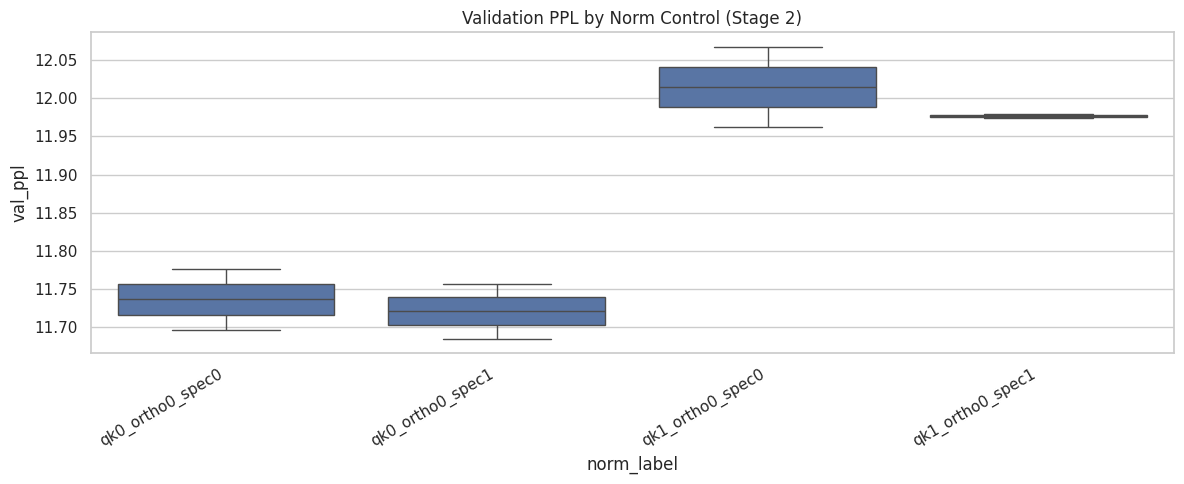

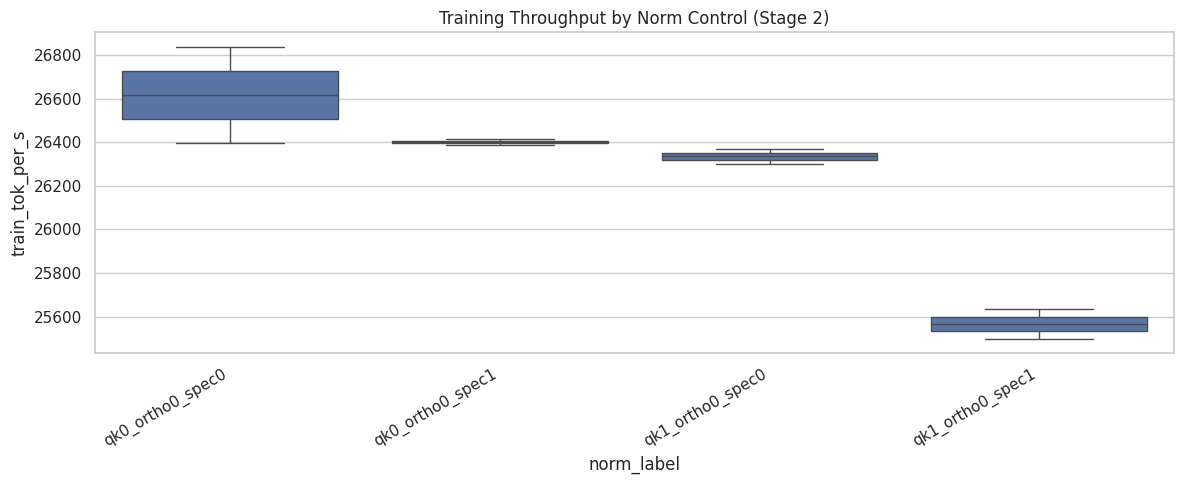

In [12]:
if len(stage2_ok) > 0:
    plt.figure(figsize=(12, 5))
    order = summary.norm_label.tolist()
    sns.boxplot(data=stage2_ok, x="norm_label", y="val_ppl", order=order)
    plt.xticks(rotation=30, ha="right")
    plt.title("Validation PPL by Norm Control (Stage 2)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    sns.boxplot(data=stage2_ok, x="norm_label", y="train_tok_per_s", order=order)
    plt.xticks(rotation=30, ha="right")
    plt.title("Training Throughput by Norm Control (Stage 2)")
    plt.tight_layout()
    plt.show()

In [13]:
!zip -r runs.zip runs

  adding: runs/ (stored 0%)
  adding: runs/sparse_norm_control_tuning_20260308_220604/ (stored 0%)
  adding: runs/sparse_norm_control_tuning_20260308_220604/stage1_top_norms.csv (deflated 49%)
  adding: runs/sparse_norm_control_tuning_20260308_220604/stage1_results.csv (deflated 74%)
  adding: runs/sparse_norm_control_tuning_20260308_220604/best_sparse_norm_config.yaml (deflated 45%)
  adding: runs/sparse_norm_control_tuning_20260308_220604/stage2_results.csv (deflated 71%)
  adding: runs/sparse_norm_control_tuning_20260308_220604/stage1/ (stored 0%)
  adding: runs/sparse_norm_control_tuning_20260308_220604/stage1/s1_qk1_ortho0_spec0_seed123/ (stored 0%)
  adding: runs/sparse_norm_control_tuning_20260308_220604/stage1/s1_qk1_ortho0_spec0_seed123/checkpoint.pt (deflated 20%)
  adding: runs/sparse_norm_control_tuning_20260308_220604/stage1/s1_qk1_ortho0_spec0_seed123/stdout.log (deflated 83%)
  adding: runs/sparse_norm_control_tuning_20260308_220604/stage1/s1_qk1_ortho0_spec0_seed123/met

In [14]:
from google.colab import files

files.download("runs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>